# DATA EXPLORATION - VANGUARD A/B TEST
---



**Question was: Would these changes encourage more clients to complete the process?**
Database Client Profiles (df_final_demo): Demographics like age, gender, and account details of our clients.
Experiment Roster (df_final_experiment_clients): A list revealing which clients were part of the grand experiment.


<h1 style="color: #8B2331;">2 | Phase 1 — IMPORT LIBRARIES </h1>

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")



<h1 style="color: #8B2331;">2 | 1. LOAD THE DATASETS </h1>

In [2]:
data_path = "data/raw_data"
df_demo = pd.read_csv(f"{data_path}/df_final_demo.txt")
df_experiment = pd.read_csv(f"{data_path}/df_final_experiment_clients.txt")

<h1 style="color: #8B2331;">2 | Phase 1 — EDA & Data Cleaning</h1>

DATASET: DEMOGRAPHICS

In [3]:
df_demo.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [4]:
df_demo.dtypes

client_id             int64
clnt_tenure_yr      float64
clnt_tenure_mnth    float64
clnt_age            float64
gendr                object
num_accts           float64
bal                 float64
calls_6_mnth        float64
logons_6_mnth       float64
dtype: object

In [5]:
df_demo.shape

(70609, 9)

DATASET: EXPERIMENT ROSTER

In [6]:
df_experiment.head()

,client_id,Variation
0,9988021,Test
1,8320017,Test
2,4033851,Control
3,1982004,Test
4,9294070,Control


In [7]:
df_experiment.shape

(70609, 2)

In [ ]:
# merging both databases
df_exde = pd.merge(df_demo, df_experiment, on='client_id', how='outer')
df_exde

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
0,169,21.0,262.0,47.5,M,2.0,501570.72,4.0,4.0,NaN
1,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test
2,647,12.0,151.0,57.5,M,2.0,30525.80,0.0,4.0,Test
3,722,11.0,143.0,59.5,F,2.0,22466.17,1.0,1.0,NaN
4,934,9.0,109.0,51.0,F,2.0,32522.88,0.0,3.0,Test
...,...,...,...,...,...,...,...,...,...,...
70604,9999400,7.0,86.0,28.5,U,2.0,51787.04,0.0,3.0,Test
70605,9999626,9.0,113.0,35.0,M,2.0,36642.88,6.0,9.0,Test
70606,9999729,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,Test
70607,9999832,23.0,281.0,49.0,F,2.0,431887.61,1.0,4.0,Test


<h1 style="color: #8B2331;">2 | Rename Columns </h1>

In [9]:
#renaming columns
df_exde.columns = df_exde.columns.str.lower().str.replace(' ', '_')
df_exde.rename(columns= {'gendr': 'gender', "bal": 'balance'}, inplace=True)


In [10]:
df_exde.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gender,num_accts,balance,calls_6_mnth,logons_6_mnth,variation
0,169,21.0,262.0,47.5,M,2.0,501570.72,4.0,4.0,NaN
1,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test
2,647,12.0,151.0,57.5,M,2.0,30525.80,0.0,4.0,Test
3,722,11.0,143.0,59.5,F,2.0,22466.17,1.0,1.0,NaN
4,934,9.0,109.0,51.0,F,2.0,32522.88,0.0,3.0,Test


In [11]:
df_exde.dtypes

client_id             int64
clnt_tenure_yr      float64
clnt_tenure_mnth    float64
clnt_age            float64
gender               object
num_accts           float64
balance             float64
calls_6_mnth        float64
logons_6_mnth       float64
variation            object
dtype: object

<h1 style="color: #8B2331;">2 | Dealing with Nulls </h1>

In [12]:
# finding nulls
df_exde.isna().sum()

client_id               0
clnt_tenure_yr         14
clnt_tenure_mnth       14
clnt_age               15
gender                 14
num_accts              14
balance                14
calls_6_mnth           14
logons_6_mnth          14
variation           20109
dtype: int64

In [13]:
df_exde.dropna(subset=['variation'], inplace=True)

In [14]:
# finding nulls
df_exde.isna().sum()

client_id            0
clnt_tenure_yr      12
clnt_tenure_mnth    12
clnt_age            13
gender              12
num_accts           12
balance             12
calls_6_mnth        12
logons_6_mnth       12
variation            0
dtype: int64

<h1 style="color: #8B2331;">2 | Standardizing Data </h1>

In [15]:
num_cols = df_exde.select_dtypes(include='number').columns

df_exde[num_cols] = df_exde[num_cols].fillna(df_exde[num_cols].median())

In [16]:
df_exde["gender"].value_counts()

gender
U    17280
M    16947
F    16259
X        2
Name: count, dtype: int64

In [17]:
# formating a column with a function
def clean_sex_column(x):
    if pd.isna(x):
        return "unknown"
    if x in ["F"]:
        return "female"
    elif x in ["M"]:
        return "male"
    elif x in ["U", "X"]:
        return "unknown"
    else:
        return "unknown"

In [18]:
df_exde['gender'] = df_exde['gender'].apply(clean_sex_column) 

In [19]:
# finding nulls
df_exde.isna().sum()

client_id           0
clnt_tenure_yr      0
clnt_tenure_mnth    0
clnt_age            0
gender              0
num_accts           0
balance             0
calls_6_mnth        0
logons_6_mnth       0
variation           0
dtype: int64

In [20]:
def age_group(x):
    if x < 30:
        return "young"
    elif 30 <= x <= 60:
        return "adult"
    else:
        return "senior"

In [21]:
df_exde["age_group"] = df_exde["clnt_age"].apply(age_group)

In [22]:
# duplicates sum
df_exde.duplicated().sum()

np.int64(0)

In [23]:
df_exde.head()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gender,num_accts,balance,calls_6_mnth,logons_6_mnth,variation,age_group
1,555,3.0,46.0,29.5,unknown,2.0,25454.66,2.0,6.0,Test,young
2,647,12.0,151.0,57.5,male,2.0,30525.80,0.0,4.0,Test,adult
4,934,9.0,109.0,51.0,female,2.0,32522.88,0.0,3.0,Test,adult
5,1028,12.0,145.0,36.0,male,3.0,103520.22,1.0,4.0,Control,adult
6,1104,5.0,66.0,48.0,unknown,3.0,154643.94,6.0,9.0,Control,adult


<h1 style="color: #8B2331;">2 | Descriptive Analysis</h1>

**Categorical Variables**

In [24]:
# descriptive analysis categorical variables 
df_exde["variation"].value_counts()

variation
Test       26968
Control    23532
Name: count, dtype: int64

In [25]:
df_exde["gender"].value_counts()

gender
unknown    17294
male       16947
female     16259
Name: count, dtype: int64

In [26]:
df_exde["age_group"].value_counts()

age_group
adult     29934
senior    12035
young      8531
Name: count, dtype: int64

In [27]:
pd.crosstab(df_exde['variation'], df_exde["age_group"] )

age_group,adult,senior,young
variation,,,
Control,13928,5669,3935
Test,16006,6366,4596


In [28]:
pd.crosstab(df_exde['variation'], df_exde["gender"] )

gender,female,male,unknown
variation,,,
Control,7543,7970,8019
Test,8716,8977,9275


In [29]:
pd.crosstab(df_exde['variation'], df_exde["gender"], normalize='index')

gender,female,male,unknown
variation,,,
Control,0.320542,0.338688,0.340770
Test,0.323198,0.332876,0.343926


In [30]:
pd.crosstab(df_exde['variation'], df_exde["age_group"])

age_group,adult,senior,young
variation,,,
Control,13928,5669,3935
Test,16006,6366,4596


In [31]:
pd.crosstab(df_exde['variation'], df_exde["age_group"], normalize='index')

age_group,adult,senior,young
variation,,,
Control,0.591875,0.240906,0.167219
Test,0.593518,0.236058,0.170424


<h1 style="color: #8B2331;">2 | Numerical variables</h1>

In [34]:
summary_stats = df_exde[['clnt_age', 'balance', 'num_accts', 'clnt_tenure_yr','logons_6_mnth', 'calls_6_mnth']].describe().round(2)
display(summary_stats)

,clnt_age,balance,num_accts,clnt_tenure_yr,logons_6_mnth,calls_6_mnth
count,50500.00,50500.00,50500.00,50500.00,50500.00,50500.00
mean,47.32,149494.77,2.25,12.03,6.13,3.09
std,15.52,302003.29,0.53,6.86,2.18,2.19
min,17.00,23789.44,1.00,2.00,3.00,0.00
25%,33.50,39881.04,2.00,6.00,4.00,1.00
50%,48.00,65733.60,2.00,11.00,6.00,3.00
75%,59.50,139938.95,2.00,16.00,8.00,5.00
max,96.00,16320040.15,7.00,55.00,9.00,6.00


Correlation coefficient: 0.9944


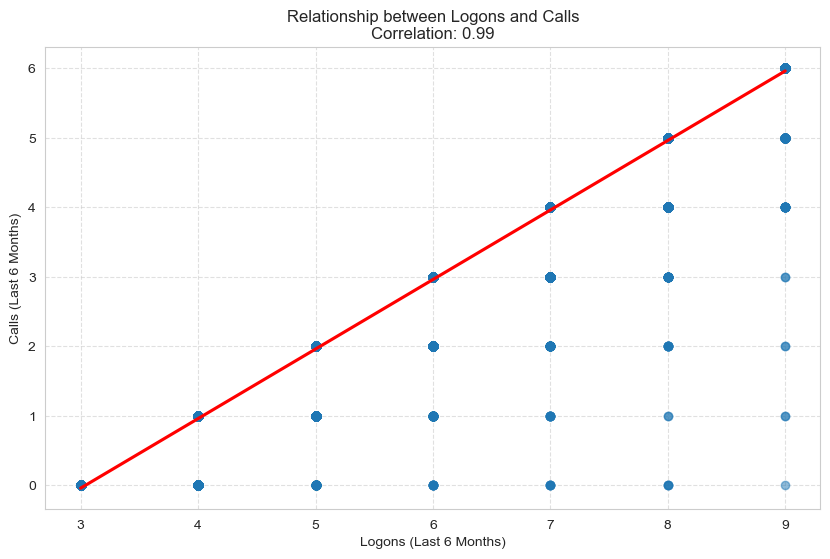

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the Pearson correlation coefficient
correlation = df_exde['logons_6_mnth'].corr(df_exde['calls_6_mnth'])
print(f"Correlation coefficient: {correlation:.4f}")

# 2. Visualize the relationship with a scatter plot
plt.figure(figsize=(10, 6))
sns.regplot(data=df_exde, x='logons_6_mnth', y='calls_6_mnth', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title(f'Relationship between Logons and Calls\nCorrelation: {correlation:.2f}')
plt.xlabel('Logons (Last 6 Months)')
plt.ylabel('Calls (Last 6 Months)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

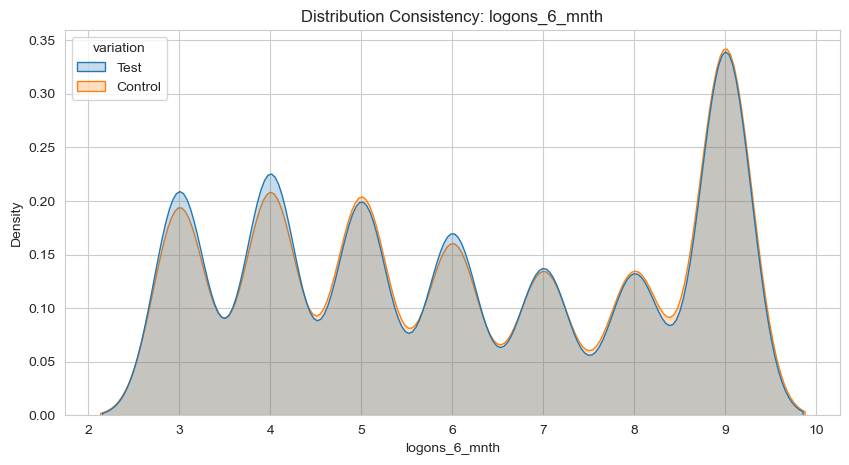

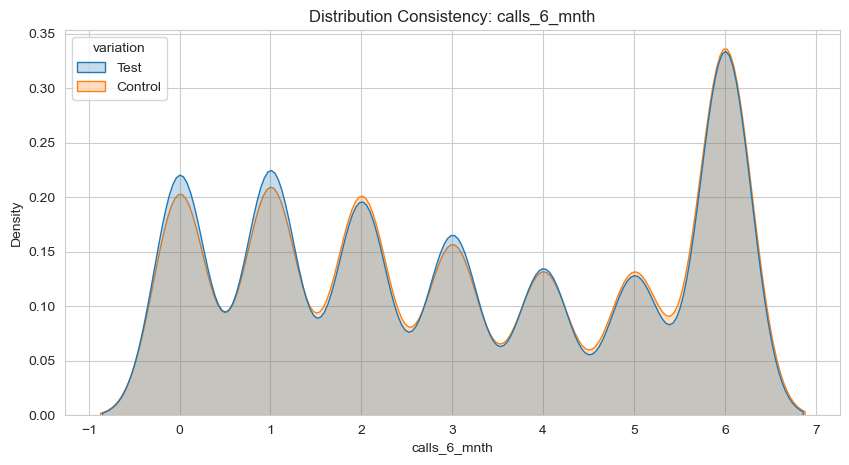

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of columns to check
cols_to_check = ['logons_6_mnth', 'calls_6_mnth']

for col in cols_to_check:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df_exde, x=col, hue='variation', fill=True, common_norm=False)
    plt.title(f'Distribution Consistency: {col}')
    plt.show()

In [ ]:
# descriptive analysis numerical variables
pd.set_option('display.float_format', '{:.2f}'.format)
df_exde.describe()

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,num_accts,balance,calls_6_mnth,logons_6_mnth
count,50500.00,50500.00,50500.00,50500.00,50500.00,50500.00,50500.00,50500.00
mean,5006179.06,12.03,150.41,47.32,2.25,149494.77,3.09,6.13
std,2877442.53,6.86,81.94,15.52,0.53,302003.29,2.19,2.18
min,555.00,2.00,33.00,17.00,1.00,23789.44,0.00,3.00
25%,2515645.75,6.00,82.00,33.50,2.00,39881.04,1.00,4.00
50%,5025103.50,11.00,136.00,48.00,2.00,65733.60,3.00,6.00
75%,7477933.25,16.00,192.00,59.50,2.00,139938.95,5.00,8.00
max,9999832.00,55.00,669.00,96.00,7.00,16320040.15,6.00,9.00


In [ ]:
df_exde.groupby('variation')['clnt_tenure_yr'].agg(['count', 'mean','std','max', 'min']).reset_index()

,variation,count,mean,std,max,min
0,Control,23532,12.09,6.88,55.00,2.00
1,Test,26968,11.98,6.84,55.00,2.00


In [ ]:
df_exde.groupby('variation')['clnt_age'].agg(['count', 'mean','std','max', 'min']).reset_index()

,variation,count,mean,std,max,min
0,Control,23532,47.50,15.52,96.00,17.00
1,Test,26968,47.16,15.51,96.00,17.00


In [ ]:
df_exde.groupby('variation')['num_accts'].agg(['count', 'mean','std','max', 'min']).reset_index()

,variation,count,mean,std,max,min
0,Control,23532,2.26,0.54,7.00,2.00
1,Test,26968,2.25,0.53,7.00,1.00


In [ ]:
df_exde.groupby('variation')['balance'].agg(['count', 'mean','std','max', 'min']).reset_index()

,variation,count,mean,std,max,min
0,Control,23532,150129.39,295778.08,8292996.21,23789.61
1,Test,26968,148941.00,307336.74,16320040.15,23789.44


In [ ]:
df_exde.groupby('variation')['calls_6_mnth'].agg(['count', 'mean','std','max', 'min']).reset_index()

,variation,count,mean,std,max,min
0,Control,23532,3.13,2.18,6.00,0.00
1,Test,26968,3.06,2.19,6.00,0.00


In [ ]:
df_exde.groupby('variation')['logons_6_mnth'].agg(['count', 'mean','std','max', 'min']).reset_index()

,variation,count,mean,std,max,min
0,Control,23532,6.17,2.17,9.00,3.00
1,Test,26968,6.10,2.18,9.00,3.00


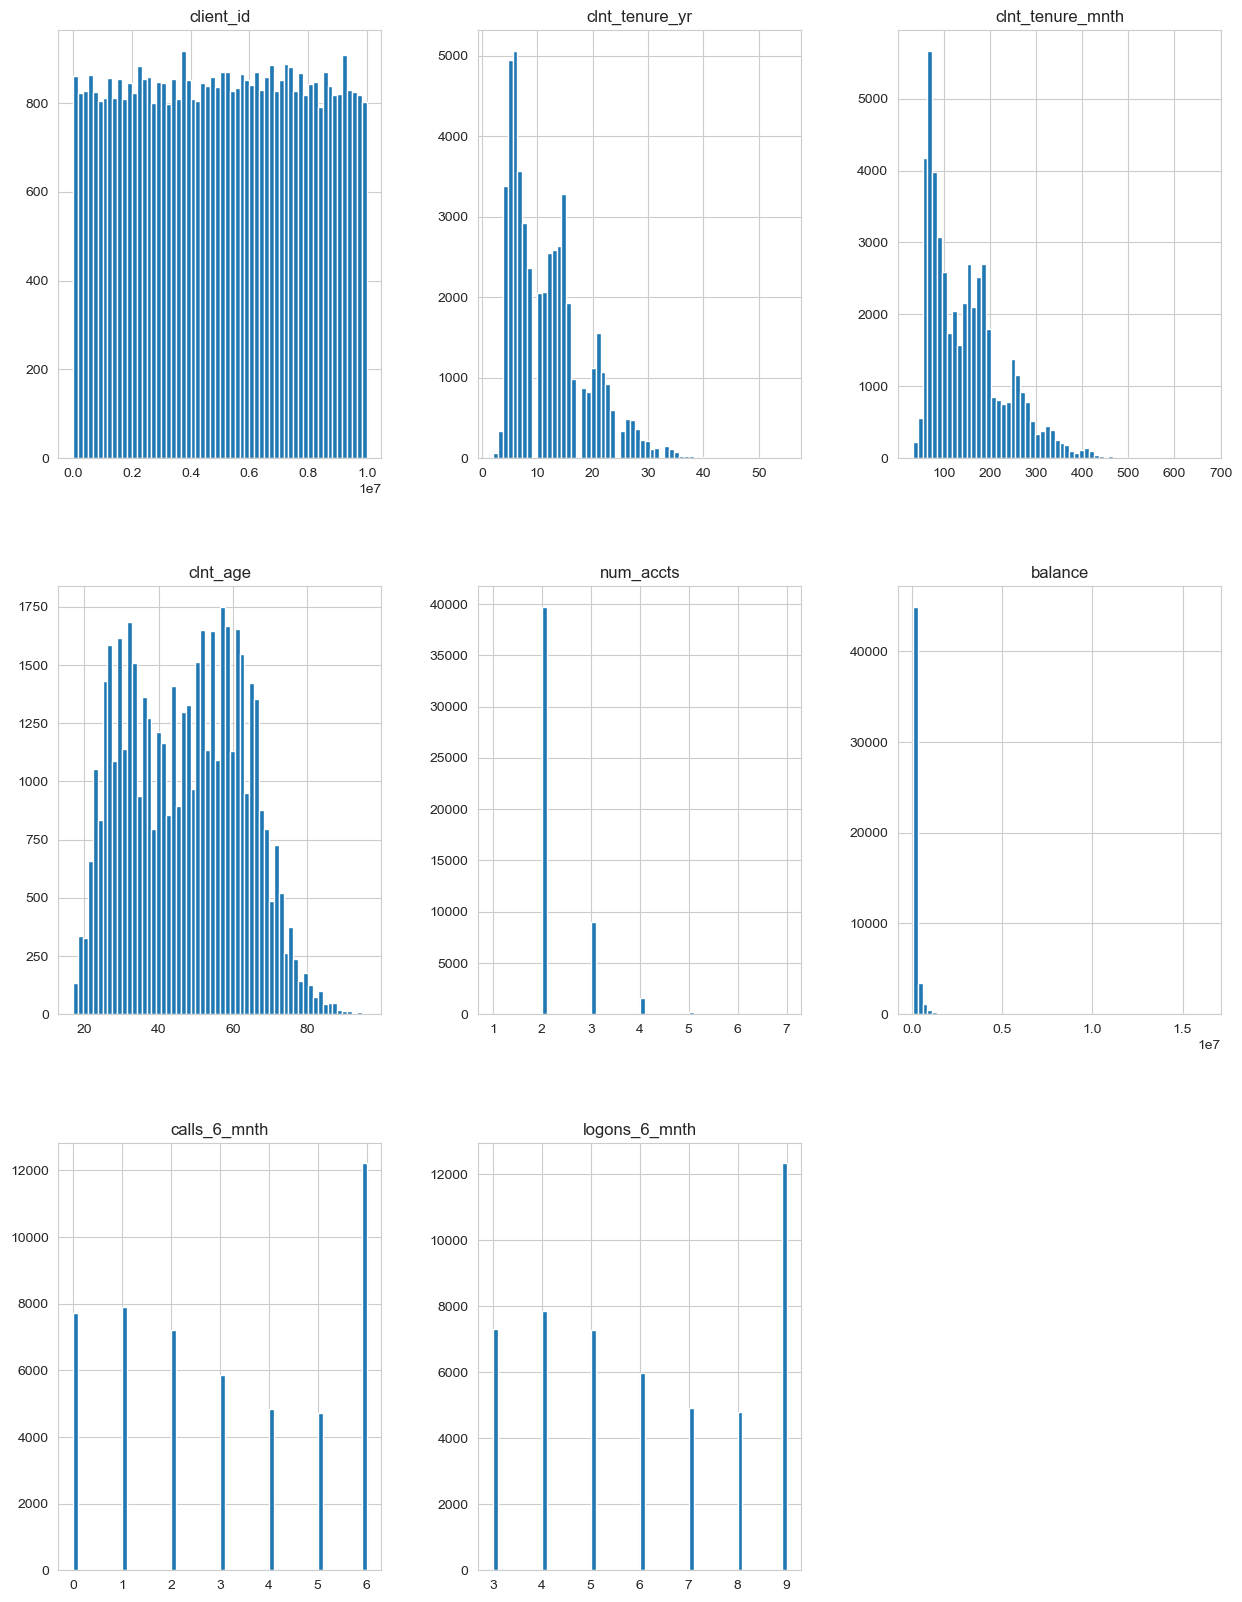

In [38]:
df_exde.hist(figsize=(15, 20), bins=60, xlabelsize=10, ylabelsize=10);
plt.show()

<h1 style="color: #8B2331;">3 | Demographic Analysis</h1>

<h2 style="color: #8B2331;"> 1. Age</h2>

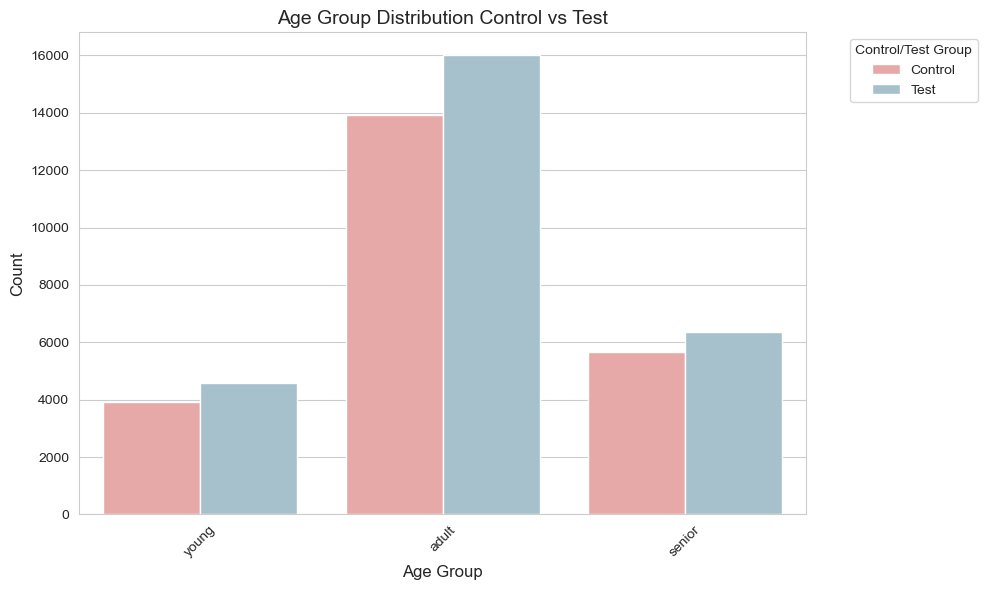

In [40]:
plt.figure(figsize=(10, 6))
vanguard_colors_subtle = ['#f29f9c', '#a0c3d2']
sns.countplot(x='age_group', hue='variation', data=df_exde, palette=vanguard_colors_subtle, hue_order=['Control', 'Test'])
plt.title('Age Group Distribution Control vs Test', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Control/Test Group', loc='upper left', bbox_to_anchor=(1.05, 1), labels=['Control', 'Test'])
plt.tight_layout()
plt.show()

## Exporting Database

In [ ]:
# exporting database
output_dir = "data/processed"
os.makedirs(output_dir, exist_ok=True)

df_exde.to_csv(f"{output_dir}/df_exde.csv", index=False)

print("Exported:")
for f in os.listdir(output_dir):
    path = os.path.join(output_dir, f)
    size = os.path.getsize(path)
    print(f"  {f} ({size:,} bytes)")

Exported:
  df_exde.csv (3,302,143 bytes)
  df_web_3.csv (81,420,206 bytes)
  vanguard.csv (57,778,112 bytes)
  vanguard_client_summary.csv (41,859,699 bytes)
  vanguard_hypo.csv (57,778,112 bytes)
  web.csv (39,957,052 bytes)
